In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [2]:
iris = sns.load_dataset('iris')
X = np.array(iris[['sepal_length', 'sepal_width']])

In [ ]:
def mcd(X, porcion=0.75, max_iter=20, tol=1e-5):

    n, _ = X.shape
    h = int(np.floor(n * porcion))
    indices = np.random.choice(n, size=h, replace=False)
    
    det_anterior = float('inf')
    
    for _ in range(max_iter):
        X_sub = X[indices]
        mu = np.mean(X_sub, axis=0)
        sigma = np.cov(X_sub, rowvar=False)
        sigma_inv = np.linalg.inv(sigma)

        det_actual = np.linalg.det(sigma)

        # si el determinante ya no disminuye significativamente
        if np.abs(det_anterior - det_actual) < tol or det_anterior < det_actual:
            break
            
        det_anterior = det_actual

        centre = X - mu
        dist_temp = np.sqrt(np.sum((centre@sigma_inv)*centre, axis=1))
        
        indices = np.argsort(dist_temp)[:h]
    
    centre = X - mu
    Maha_distance = np.sqrt(np.sum((centre@sigma_inv)*centre, axis=1))
    
    return mu, sigma, Maha_distance

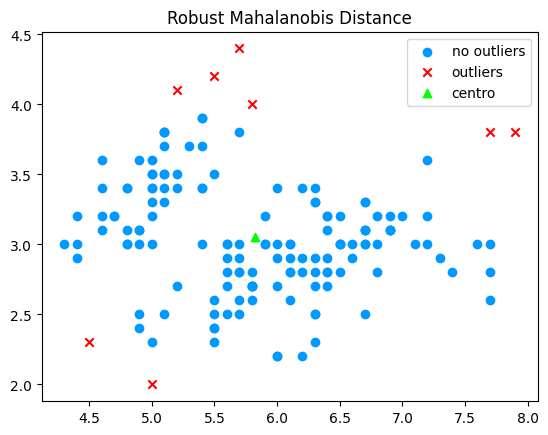

In [28]:
mu, cov_robusta, Maha_distance = mcd(X, porcion=0.8)

Maha_depth = 1 / (1+Maha_distance**2)
mask_outliers = np.percentile(Maha_depth,5) > Maha_depth
outliers = X[mask_outliers]
no_outliers = X[~mask_outliers]

plt.scatter(no_outliers[:,0], no_outliers[:,1],  marker='o', color='#0099FF', label='no outliers')
plt.scatter(outliers[:,0], outliers[:,1], marker='x',color='#FF0000', label='outliers')
plt.scatter(mu[0], mu[1], marker='^', color='#00FF00', label='centro')
plt.title('Robust Mahalanobis Distance')
plt.legend()
